In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

In [6]:


# load dataset
housing = fetch_california_housing()

# features and target
X = housing.data
y = housing.target

print(y)

# create DataFrame
df = pd.DataFrame(X, columns=housing.feature_names)
df['Price'] = y

print(df.head())


[4.526 3.585 3.521 ... 0.923 0.847 0.894]
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [7]:
df.isnull().sum()


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

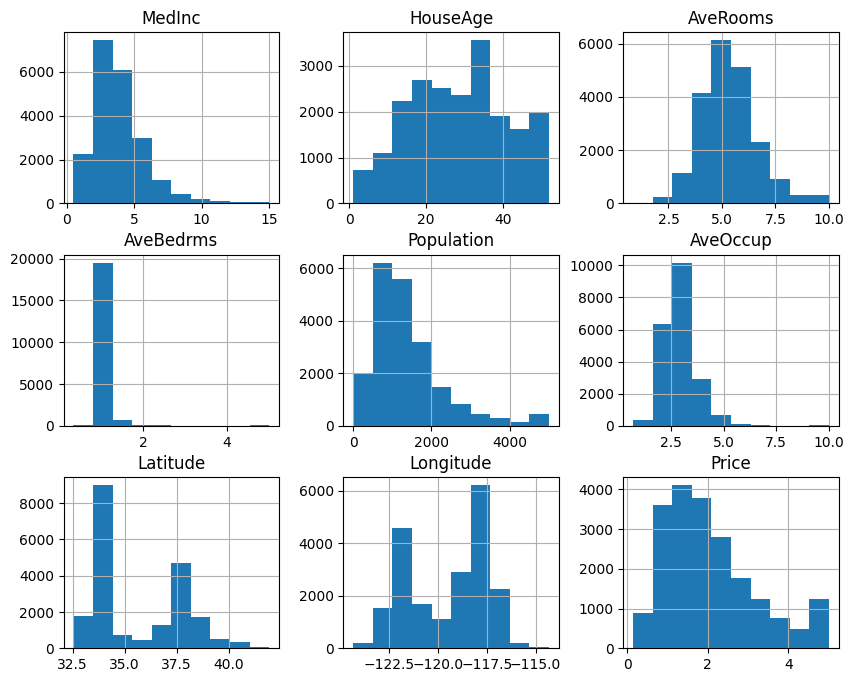

In [8]:


df["Population"] = df["Population"].clip(upper=5000)
df["AveRooms"] = df["AveRooms"].clip(upper=10)
df["AveBedrms"] = df["AveBedrms"].clip(upper=5)
df["AveOccup"]  = df["AveOccup"].clip(upper=10)

df.hist(figsize=(10, 8))
plt.show()

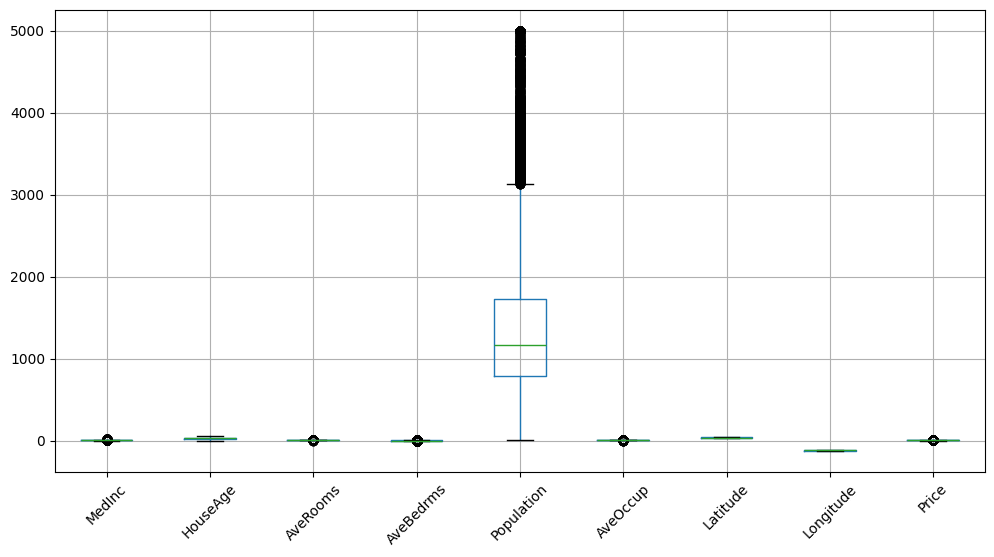

In [9]:





df.boxplot(figsize=(12, 6))
plt.xticks(rotation=45)
plt.show()

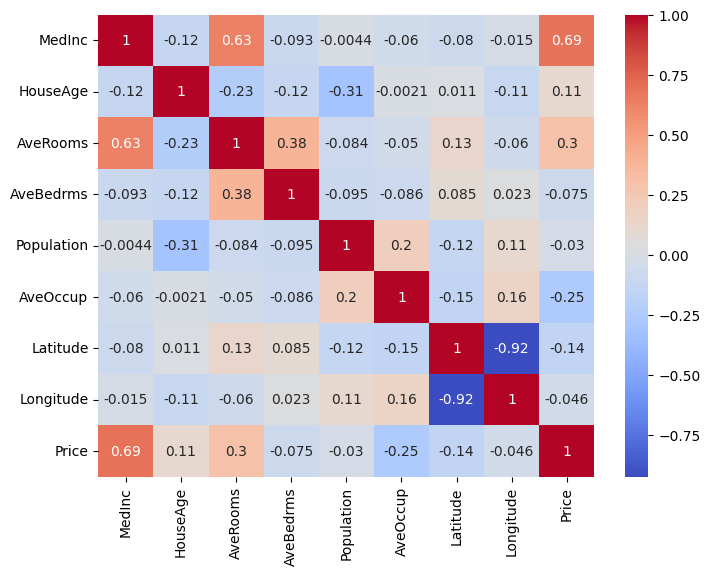

In [14]:
corr = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

hence Pricing is most impacted by "MedInc" in a direct relation, while, by "latitude" in an inverse relation.

MAE: 0.5332001304956555
MSE: 0.5558915986952443
R2 Score: 0.5757877060324508


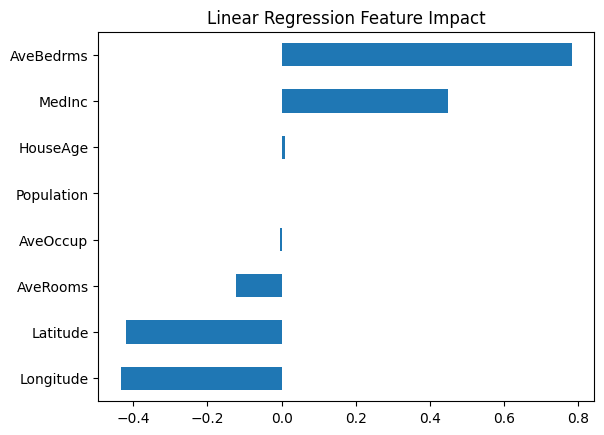

In [32]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


importance = pd.Series(model.coef_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Linear Regression Feature Impact")
plt.show()



In [33]:
new_house = pd.DataFrame(
    [[80.0, 25.0, 6.0, 1.0, 1500.0, 3.0, 34.0, -118.0]],
    columns=X.columns
)
print(new_house)
pred = model.predict(new_house)
pred *= 100000 #add a scale
print("Predicted Price:", pred[0])

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0    80.0      25.0       6.0        1.0      1500.0       3.0      34.0   

   Longitude  
0     -118.0  
Predicted Price: 3604801.0090380856


MAE: 0.4557622892441861
MSE: 0.4997071473927568
R2 Score: 0.6186632145457622


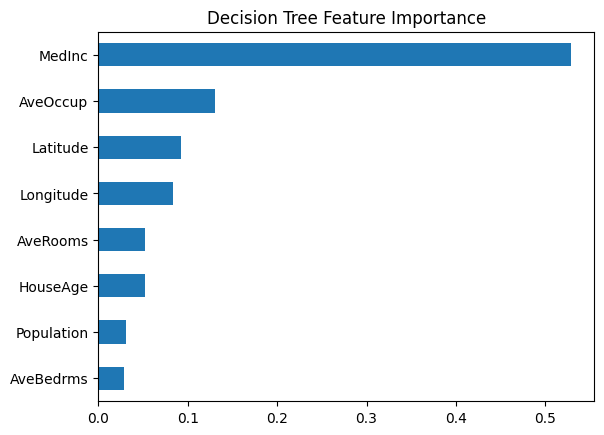

Predict Price:  2.866


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# -----------------------------
# STEP 1: Load dataset
# -----------------------------
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target


# -----------------------------
# STEP 2: Features and target
# -----------------------------
X_dt = df.drop('Price', axis=1)
y = df['Price']


# -----------------------------
# STEP 3: Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_dt, y,
    test_size=0.2,
    random_state=42
)


# -----------------------------
# STEP 4: Train model
# -----------------------------
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)


# -----------------------------
# STEP 5: Predictions
# -----------------------------
y_pred = model.predict(X_test)


# -----------------------------
# STEP 6: Evaluation
# -----------------------------
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


# -----------------------------
# STEP 7: Feature importance
# -----------------------------
importance = pd.Series(model.feature_importances_, index=X_dt.columns)

importance.sort_values().plot(kind='barh')
plt.title("Decision Tree Feature Importance")
plt.show()



   

In [86]:
new_house = pd.DataFrame(
    [[8.0, 25.0, 6.0, 1.0, 1500.0, 3.0, 34.0, -118.0]],
    columns=X_dt.columns
)
pred = model.predict(new_house)
pred *= 100000 #add a scale
print("Predict Price: $",pred[0])

Predict Price: $ 286600.0
